# Wave-front GIF maker

Build an animated GIF of TopoLines wave-front propagation — the same reveal the
site plays live. Default input is `examples/einstein.jpg`.

Pipeline: grayscale → blur → eikonal travel time → iso-contours by level → frames → GIF.

In [25]:
# If packages are missing:
#   python3.12 -m venv .venv
#   .venv/bin/pip install -r requirements.txt
#   .venv/bin/python -m ipykernel install --user --name topolines --display-name "TopoLines"

from pathlib import Path

import numpy as np
import skfmm
from IPython.display import Image as IPyImage, display
from PIL import Image, ImageDraw
from scipy.ndimage import gaussian_filter
from skimage import measure

print("skfmm", getattr(skfmm, "__version__", "ok"))

skfmm 2025.06.23


## Settings

Defaults match the site’s Einstein example (`blur=1`, `ε=0.1`, `L=8`, center seed).
Tweak here, then re-run the cells below.

In [26]:
IMAGE_PATH = Path("examples/einstein.jpg")
OUT_PATH = Path("examples/einstein_wave.gif")

# Updated settings per user instructions
BLUR_SIGMA = 1.0            # Blur σ
SPEED_EPS = 0.10            # Speed ε
STRIPE_SPACING = 8.0        # L (spacing)
SEED_MODE = "center"        # "center" | "scatter" | "edge"
N_SCATTER = 5
LINE_WIDTH = 1.00           # Line width
MAX_SIDE = 512              # Max side (px)

# Animation
FRAME_MS = 40               # ms per level frame
HOLD_FINAL_MS = 800         # pause on the finished drawing before looping
FRONT_COLOR = (31, 138, 112)   # #1f8a70 — same accent as the live reveal
LINE_COLOR = (17, 17, 17)      # #111
BG_COLOR = (255, 255, 255)

## Solve for travel time

In [27]:
def load_grayscale(path: Path) -> np.ndarray:
    rgb = np.asarray(Image.open(path).convert("RGB"), dtype=np.float64)
    gray = 0.299 * rgb[..., 0] + 0.587 * rgb[..., 1] + 0.114 * rgb[..., 2]
    return np.clip(gray / 255.0, 0.0, 1.0)


def preprocess(image: np.ndarray, blur_sigma: float = BLUR_SIGMA) -> np.ndarray:
    img = image.astype(np.float64)
    lo, hi = img.min(), img.max()
    if hi > lo:
        img = (img - lo) / (hi - lo)
    if blur_sigma > 0:
        img = np.clip(gaussian_filter(img, sigma=blur_sigma), 0.0, 1.0)
    return img


def make_seeds(
    shape: tuple[int, int],
    mode: str = SEED_MODE,
    n_scatter: int = N_SCATTER,
    rng: np.random.Generator | None = None,
) -> list[tuple[int, int]]:
    h, w = shape
    if mode == "center":
        return [(h // 2, w // 2)]
    if mode == "scatter":
        rng = rng or np.random.default_rng(0)
        margin = max(8, min(h, w) // 16)
        ys = rng.integers(margin, h - margin, size=n_scatter)
        xs = rng.integers(margin, w - margin, size=n_scatter)
        return list(zip(ys.tolist(), xs.tolist()))
    if mode == "edge":
        step = max(1, h // 64)
        return [(y, 0) for y in range(0, h, step)]
    raise ValueError(f"unknown seed mode: {mode!r}")


def resize_max_side(img: np.ndarray, max_side: int) -> np.ndarray:
    h, w = img.shape
    scale = max_side / max(h, w)
    if scale >= 1.0:
        return img
    nh, nw = max(1, round(h * scale)), max(1, round(w * scale))
    pil = Image.fromarray((img * 255).astype(np.uint8), mode="L")
    pil = pil.resize((nw, nh), Image.Resampling.LANCZOS)
    return np.asarray(pil, dtype=np.float64) / 255.0


raw = load_grayscale(IMAGE_PATH)
image = preprocess(resize_max_side(raw, MAX_SIDE), blur_sigma=BLUR_SIGMA)
speed = SPEED_EPS + image
seeds = make_seeds(image.shape, mode=SEED_MODE, n_scatter=N_SCATTER)

phi = np.ones(image.shape, dtype=np.float64)
for y, x in seeds:
    phi[y, x] = -1.0

T = skfmm.travel_time(phi, speed)
h, w = image.shape
print(f"image={w}×{h}, seeds={len(seeds)} ({SEED_MODE}), T∈[{T.min():.2f}, {T.max():.2f}]")

image=401×512, seeds=1 (center), T∈[0.41, 821.76]


## Contours by travel-time level

Same ordering as the site’s live reveal: each level is one wavefront step.

In [28]:
def extract_contours_by_level(T: np.ndarray, L: float) -> list[list[np.ndarray]]:
    """Iso-contours grouped by increasing travel-time level (0, L, 2L, …)."""
    levels: list[list[np.ndarray]] = []
    for level in np.arange(0.0, float(np.nanmax(T)), L):
        levels.append(measure.find_contours(T, level))
    return levels


levels = extract_contours_by_level(T, STRIPE_SPACING)
n_polys = sum(len(p) for p in levels)
print(f"{len(levels)} levels · {n_polys} polylines · L={STRIPE_SPACING}")

103 levels · 239 polylines · L=8.0


## Render frames and write GIF

Settled contours are dark; the newest level (the wavefront) is drawn thicker in the accent color.

In [29]:
def stroke_polys(
    draw: ImageDraw.ImageDraw,
    polys: list[np.ndarray],
    *,
    color: tuple[int, int, int],
    width: float,
) -> None:
    lw = max(1, int(round(width)))
    for poly in polys:
        if len(poly) < 2:
            continue
        # find_contours → (row, col) == (y, x); PIL wants (x, y)
        pts = [(float(x), float(y)) for y, x in poly]
        draw.line(pts, fill=color, width=lw, joint="curve")


def render_frame(
    settled: list[np.ndarray],
    front: list[np.ndarray] | None,
    *,
    size: tuple[int, int],
    lw: float,
) -> Image.Image:
    w, h = size
    img = Image.new("RGB", (w, h), BG_COLOR)
    draw = ImageDraw.Draw(img)
    stroke_polys(draw, settled, color=LINE_COLOR, width=lw)
    if front:
        front_lw = max(lw * 1.6, lw + 0.35)
        stroke_polys(draw, front, color=FRONT_COLOR, width=front_lw)
    return img


def make_wave_gif(
    levels: list[list[np.ndarray]],
    out_path: Path,
    *,
    size: tuple[int, int],
    lw: float = LINE_WIDTH,
    frame_ms: int = FRAME_MS,
    hold_final_ms: int = HOLD_FINAL_MS,
) -> list[Image.Image]:
    w, h = size
    frames: list[Image.Image] = []
    settled: list[np.ndarray] = []

    for i, front in enumerate(levels):
        frames.append(render_frame(settled, front, size=(w, h), lw=lw))
        settled.extend(front)

    # Final frame: all lines settled, no accent front
    frames.append(render_frame(settled, None, size=(w, h), lw=lw))

    durations = [frame_ms] * (len(frames) - 1) + [hold_final_ms]
    out_path.parent.mkdir(parents=True, exist_ok=True)
    frames[0].save(
        out_path,
        save_all=True,
        append_images=frames[1:],
        duration=durations,
        loop=0,
        optimize=True,
    )
    return frames


frames = make_wave_gif(levels, OUT_PATH, size=(w, h))
kb = OUT_PATH.stat().st_size / 1024
print(f"wrote {OUT_PATH} · {len(frames)} frames · {kb:.0f} KB")

wrote examples/einstein_wave.gif · 104 frames · 202 KB


## Preview

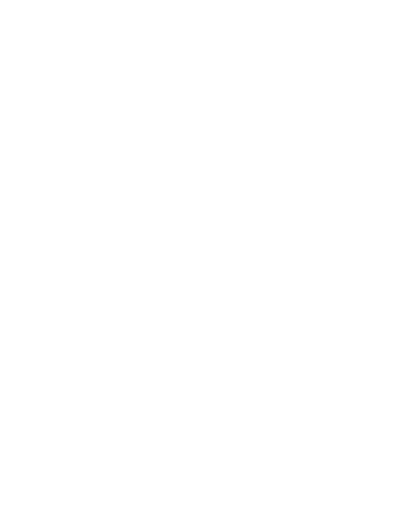

In [30]:
display(IPyImage(filename=str(OUT_PATH)))